# TCGA MC3 Somatic Mutation Processing

## Overview

This notebook implements a complete preprocessing and quality-control pipeline for somatic mutation data derived from the TCGA pan-cancer MC3 cohort. The workflow is designed to transform raw Mutation Annotation Format (MAF) files into a clean, analysis-ready binary mutation matrix suitable for downstream multi-omics integration, graph-based learning, and cancer driver gene analysis.

The pipeline integrates somatic mutation data with RNA-seq gene expression profiles and gene annotation information from GENCODE (v38), ensuring consistent genomic coordinates and gene identifiers across multiple omics layers.

---

## Objectives

The main goals of this pipeline are:

- Process raw MC3 MAF somatic mutation data into structured format  
- Standardize tumor sample identifiers across omics datasets  
- Filter functionally relevant (deleterious) mutations  
- Construct gene-by-sample mutation matrices (binary and weighted)  
- Integrate mutation data with RNA-seq expression profiles  
- Restrict analysis to protein-coding genes using GENCODE annotation  
- Normalize expression data for downstream modeling  
- Perform quality-control checks and exploratory visualizations  

---

## Data Sources

- **Somatic mutations (MC3):** TCGA Multi-Center Mutation Calling dataset  
  https://gdc.cancer.gov/about-data/publications/mc3-2017  

- **Gene expression (RNA-seq):** Pan-Cancer Atlas (UCSC Xena platform)  
  https://xenabrowser.net/datapages/  

- **Gene annotation:** GENCODE v38  
  https://www.gencodegenes.org/human/release_38.html  

---

## Key Processing Steps

### 1. Mutation Data Loading and Filtering
- Load raw MAF file
- Retain essential columns (gene symbol, sample barcode, variant classification)
- Extract standardized sample IDs (first 15 characters of TCGA barcode)

### 2. Functional Mutation Selection
- Keep only deleterious variant classes:
  frameshift insertions/deletions, nonsense mutations, splice-site variants, etc.
- Remove non-functional mutation categories

### 3. Mutation Matrix Construction
- Aggregate mutations into a gene-by-sample matrix
- Remove duplicate gene–sample mutation events
- Generate:
  - Binary mutation matrix (presence/absence)
  - Weighted mutation matrix (normalized counts)

### 4. Expression Data Processing
- Load RNA-seq gene expression matrix
- Remove low-quality genes (all-zero expression)
- Standardize sample identifiers
- Log-transform and z-score normalize expression values

### 5. Gene Annotation and Filtering
- Parse GENCODE v38 GTF annotation
- Retain protein-coding genes only
- Align gene sets across mutation and expression data

### 6. Multi-Omics Alignment
- Intersect gene sets across mutation and expression modalities
- Match sample identifiers across datasets
- Ensure consistent feature space for downstream modeling

---

## Outputs

The pipeline generates:

- `mut_binary`: Binary gene-by-sample mutation matrix  
- `mut_weighted`: Normalized mutation burden matrix  
- `expr_clean`: Normalized RNA-seq expression matrix  
- Filtered and aligned multi-omics feature space  

---

## Visualization and Quality Control

The notebook includes exploratory analyses such as:

- Distribution of mutation burden per sample  
- Top frequently mutated genes  
- Proportion of deleterious vs non-deleterious mutations  

These checks ensure biological plausibility and dataset consistency before downstream modeling.

---

## Downstream Applications

This processed dataset is designed for:

- Graph Neural Network (GNN) modeling  
- Multi-omics cancer driver gene prediction  
- Embedding learning for patient stratification  
- Network-based functional genomics analysis  

In [1]:
import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt
import json, requests, gzip, re, os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
# from tqdm import tqdm
import gseapy as gp
from tqdm.auto import tqdm
print(os.getcwd())

/mnt/c/2024_Winter/gnn/ASPIRE_GNN_/process


In [2]:
# # Input file
# maf_file = "../data/_maf_mc3/mc3.v0.2.8.PUBLIC.maf"
# output_file = "data/TCGA-PAN.mutation.tsv"
# GTF_PATH = "../data/gdc_cache/gencode.v38.annotation.gtf.gz"
# # Open gzipped file with pandas (skip '#' comment lines)
# maf = pd.read_csv(
#     maf_file,
#     sep="\t",
#     comment="#",
#     low_memory=False
# )

# print("Loaded MAF:", maf.shape)
# maf.head()


import pandas as pd

# Input file
maf_file = "../data/_maf_mc3/mc3.v0.2.8.PUBLIC.maf"
output_file = "data/TCGA-PAN.mutation.tsv"
GTF_PATH = "../data/gdc_cache/gencode.v49.annotation.gtf.gz"

# maf_file = "mc3.v0.2.8.PUBLIC.maf.gz"  

chunksize = 1_000_000  # 1M rows per chunk

selected_cols = [
    "Hugo_Symbol",
    "Tumor_Sample_Barcode",
    "Variant_Classification"
]

dfs = []

for chunk in pd.read_csv(
    maf_file,
    sep="\t",
    comment="#",
    usecols=selected_cols,
    chunksize=chunksize,
    # compression="gzip",
    low_memory=True
):
    # OPTIONAL: filter early to reduce memory
    chunk = chunk[chunk["Variant_Classification"] != "Silent"]

    dfs.append(chunk)

maf = pd.concat(dfs, ignore_index=True)

print("✅ Loaded MAF:", maf.shape)

## gene-level mutation counts

# from collections import Counter
# import pandas as pd

# maf_file = "mc3.v0.2.8.PUBLIC.maf.gz"

# gene_counts = Counter()

# for chunk in pd.read_csv(
#     maf_file,
#     sep="\t",
#     comment="#",
#     usecols=["Hugo_Symbol", "Variant_Classification"],
#     chunksize=1_000_000,
#     compression="gzip"
# ):
#     chunk = chunk[chunk["Variant_Classification"] != "Silent"]

#     counts = chunk["Hugo_Symbol"].value_counts()
#     gene_counts.update(counts.to_dict())

# # Convert to DataFrame
# gene_mut = pd.DataFrame.from_dict(gene_counts, orient="index", columns=["mut_count"])
# gene_mut = gene_mut.sort_values("mut_count", ascending=False)

# print(gene_mut.head())

✅ Loaded MAF: (2818276, 3)


In [3]:
cols_needed = [
    "Hugo_Symbol",
    "Tumor_Sample_Barcode",
    "Variant_Classification"
]

maf = maf[cols_needed].copy()



In [4]:
maf["Sample"] = maf["Tumor_Sample_Barcode"].str[:15]
maf.rename(columns={"Hugo_Symbol": "Gene"}, inplace=True)

In [5]:
deleterious_classes = {
    "Frame_Shift_Del",
    "Frame_Shift_Ins",
    "Nonsense_Mutation",
    "Splice_Site",
    "Nonstop_Mutation",
    "Translation_Start_Site"
}

maf["Deleterious"] = maf["Variant_Classification"].isin(deleterious_classes)
maf = maf[maf["Deleterious"]]
maf = maf.drop_duplicates(subset=["Gene", "Sample"])

mut_counts = (
    maf.groupby(["Gene", "Sample"])
       .size()
       .unstack(fill_value=0)
)

mut_binary = (mut_counts > 0).astype(int)



In [6]:
print(mut_binary.shape)
mut_binary.head()

(19018, 9787)


Sample,TCGA-02-0033-01,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2466-01,TCGA-02-2470-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-04-1331-01,TCGA-04-1335-01,...,TCGA-ZQ-A9CR-01,TCGA-ZR-A9CJ-01,TCGA-ZS-A9CD-01,TCGA-ZS-A9CE-01,TCGA-ZS-A9CF-01,TCGA-ZS-A9CF-02,TCGA-ZS-A9CG-01,TCGA-ZT-A8OM-01,TCGA-ZU-A8S4-01,TCGA-ZX-AA5X-01
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2ML1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A3GALT2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
mut_weighted = maf.groupby(["Gene", "Sample"]).size().unstack(fill_value=0)

# normalize per sample
mut_weighted = mut_weighted.div(mut_weighted.sum(axis=0), axis=1)

In [8]:
print(mut_weighted.shape)
mut_binary.head()

(19018, 9787)


Sample,TCGA-02-0033-01,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2466-01,TCGA-02-2470-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-04-1331-01,TCGA-04-1335-01,...,TCGA-ZQ-A9CR-01,TCGA-ZR-A9CJ-01,TCGA-ZS-A9CD-01,TCGA-ZS-A9CE-01,TCGA-ZS-A9CF-01,TCGA-ZS-A9CF-02,TCGA-ZS-A9CG-01,TCGA-ZT-A8OM-01,TCGA-ZU-A8S4-01,TCGA-ZX-AA5X-01
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2ML1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A3GALT2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
import pandas as pd

expr = pd.read_csv(
    "../data/_xena/EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena",
    sep="\t"
)

# rename first column
expr.rename(columns={expr.columns[0]: "Gene"}, inplace=True)

In [10]:
# import os
# import subprocess

# GTF_PATH = "../data/gdc_cache/gencode.v49.annotation.gtf.gz"
# os.makedirs(os.path.dirname(GTF_PATH), exist_ok=True)

# if not os.path.exists(GTF_PATH):
#     print("⬇️ Downloading GENCODE v38 GTF...")

#     subprocess.run([
#         "curl",
#         "-L",
#         "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_38/gencode.v38.annotation.gtf.gz",
#         "-o",
#         GTF_PATH
#     ], check=True)

#     print(f"✅ Saved → {GTF_PATH}")
# else:
#     print(f"✅ Already exists → {GTF_PATH}")

In [11]:
import pandas as pd
import numpy as np

# -------------------------------
# 1. Remove all-zero genes
# -------------------------------
expr = expr.loc[(expr.iloc[:, 1:] != 0).any(axis=1)]

# -------------------------------
# 2. Standardize sample IDs
# -------------------------------
expr.columns = ["Gene"] + [c[:15] for c in expr.columns[1:]]

# -------------------------------
# 3. Separate gene + numeric
# -------------------------------
gene_col = expr["Gene"]
expr_numeric = expr.drop(columns=["Gene"])

# force numeric
expr_numeric = expr_numeric.apply(pd.to_numeric, errors="coerce")

# -------------------------------
# 4. Remove duplicate samples safely
# -------------------------------
# expr_numeric = expr_numeric.groupby(expr_numeric.columns, axis=1).mean()

expr_numeric = (
    expr_numeric.T
    .groupby(expr_numeric.columns, sort=False)
    .mean()
    .T
)

# recombine
expr = pd.concat([gene_col, expr_numeric], axis=1)

# -------------------------------
# 5. Match samples with mutation
# -------------------------------
common_samples = list(set(expr.columns[1:]) & set(mut_binary.columns))

expr = expr[["Gene"] + common_samples]
mut_binary = mut_binary[common_samples]


gtf = pd.read_csv(
    GTF_PATH,
    sep="\t",
    comment="#",
    header=None,
    compression="gzip",
    names=[
        "chr", "source", "feature", "start", "end",
        "score", "strand", "frame", "attribute"
    ]
)



# -------------------------------
# 6. Keep protein-coding genes
# -------------------------------
gtf = gtf[gtf["feature"] == "gene"]

# extract fields
gtf["gene_id"] = gtf["attribute"].str.extract('gene_id "([^"]+)"')
gtf["gene_name"] = gtf["attribute"].str.extract('gene_name "([^"]+)"')
gtf["gene_type"] = gtf["attribute"].str.extract('gene_type "([^"]+)"')

print(gtf.head())
print(gtf.shape)

protein_coding = set(
    gtf[gtf["gene_type"] == "protein_coding"]["gene_name"]
)


expr = expr[expr["Gene"].isin(protein_coding)]

# -------------------------------
# 7. Align genes
# -------------------------------
common_genes = list(set(expr["Gene"]) & set(mut_binary.index))

expr = expr[expr["Gene"].isin(common_genes)]
mut_binary = mut_binary.loc[common_genes]

# -------------------------------
# 8. Normalize expression
# -------------------------------
expr_vals = expr.set_index("Gene")

expr_vals = np.log1p(expr_vals)

expr_vals = expr_vals.sub(expr_vals.mean(axis=1), axis=0)
expr_vals = expr_vals.div(expr_vals.std(axis=1) + 1e-8, axis=0)

expr_clean = expr_vals.reset_index()

# -------------------------------
# 9. Final checks
# -------------------------------
print(expr_clean.shape)
print(mut_binary.shape)

print(set(expr_clean["Gene"]) == set(mut_binary.index))
print(set(expr_clean.columns[1:]) == set(mut_binary.columns))

       chr   source feature  start    end score strand frame  \
0     chr1   HAVANA    gene  11121  24894     .      +     .   
124   chr1   HAVANA    gene  12010  13670     .      +     .   
132   chr1   HAVANA    gene  14356  30744     .      -     .   
2403  chr1   HAVANA    gene  14696  24886     .      -     .   
2415  chr1  ENSEMBL    gene  17369  17436     .      -     .   

                                              attribute            gene_id  \
0     gene_id "ENSG00000290825.2"; gene_type "lncRNA...  ENSG00000290825.2   
124   gene_id "ENSG00000223972.6"; gene_type "transc...  ENSG00000223972.6   
132   gene_id "ENSG00000310526.1"; gene_type "lncRNA...  ENSG00000310526.1   
2403  gene_id "ENSG00000227232.6"; gene_type "transc...  ENSG00000227232.6   
2415  gene_id "ENSG00000278267.1"; gene_type "miRNA"...  ENSG00000278267.1   

      gene_name                           gene_type  
0      DDX11L16                              lncRNA  
124     DDX11L1  transcribed_unprocess

/home/eric_karma/anaconda3/envs/reactome_gnn/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
/home/eric_karma/anaconda3/envs/reactome_gnn/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


(15997, 9174)
(15997, 9173)
True
True


In [12]:
output_file = "data/TCGA-PAN.mutation.tsv"
maf.to_csv(output_file, sep="\t", index=False)
print("Saved:", output_file)

print(os.getcwd())

Saved: data/TCGA-PAN.mutation.tsv
/mnt/c/2024_Winter/gnn/ASPIRE_GNN_/process


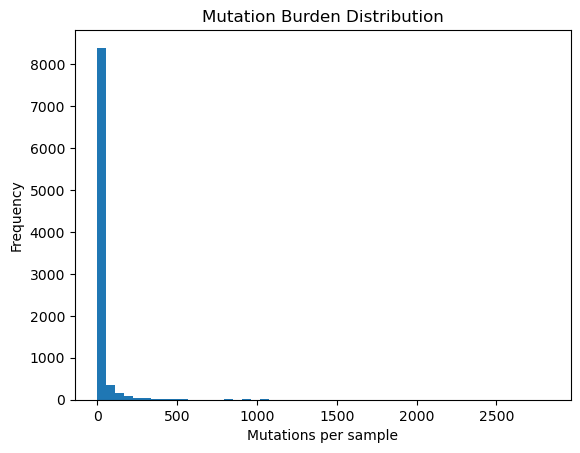

In [13]:
mut_per_sample = mut_binary.sum(axis=0)

plt.figure()
plt.hist(mut_per_sample, bins=50)
plt.xlabel("Mutations per sample")
plt.ylabel("Frequency")
plt.title("Mutation Burden Distribution")
plt.show()

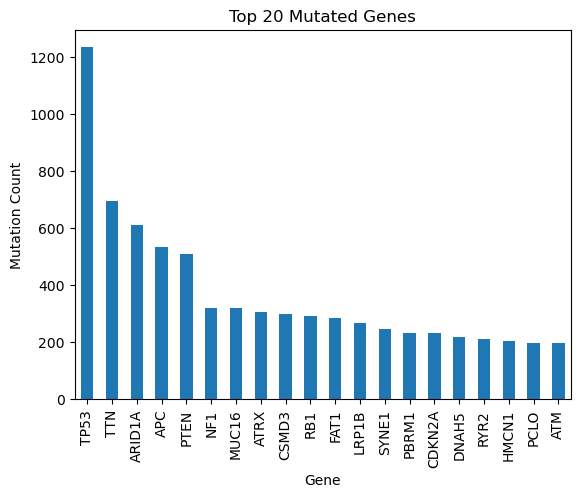

In [14]:
top_genes = mut_binary.sum(axis=1).sort_values(ascending=False).head(20)

plt.figure()
top_genes.plot(kind="bar")
plt.title("Top 20 Mutated Genes")
plt.xlabel("Gene")
plt.ylabel("Mutation Count")
plt.xticks(rotation=90)
plt.show()

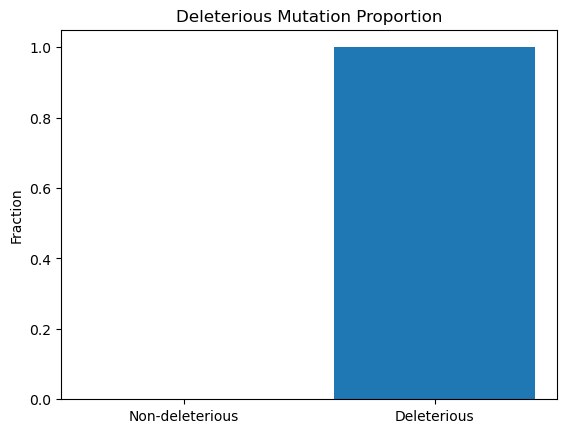

In [15]:
deleterious_ratio = maf["Deleterious"].mean()

plt.figure()
plt.bar(["Non-deleterious", "Deleterious"], [1 - deleterious_ratio, deleterious_ratio])
plt.title("Deleterious Mutation Proportion")
plt.ylabel("Fraction")
plt.show()